# **PCA for Breast Cancer**


---


*Data Set used:  sklearn.datasets.load_breastcancer()*

In [ ]:
# Q1_pca_breast_cancer.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
# (a)
# Standardize
breast_cancer_data = datasets.load_breast_cancer()
X = breast_cancer_data.data
Y = breast_cancer_data.target   # 0=malignant, 1=benign
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Covariance and Frobenius norm
S = np.cov(X_std, rowvar=False)
print("Shape of covariance matrix S:", S.shape)
frob_norm = np.linalg.norm(S, ord='fro')
print("Frobenius norm of S =", frob_norm)

Shape of covariance matrix S: (30, 30)
Frobenius norm of S = 15.062350986709808


In [ ]:
# (b)
# Top-k eigenpairs (k=2)
from sklearn.decomposition import PCA
pca2 = PCA(n_components=2)
pca2.fit(X_std)
eigenval1, eigenval2 = pca2.explained_variance_
explained_pct = pca2.explained_variance_ratio_ * 100
cum_pct = explained_pct.cumsum()
eigen_vector1 = pca2.components_[0]
eigen_vector2 = pca2.components_[1]
print("=== PCA Results (k=2) ===")
print("\n(i) eigenval1, eigenval2:", eigenval1, eigenval2)
print("\nEigenvector for first Eigen Value (PC1):")
print(eigen_vector1)
print("\nEigenvector for seconf Eigen Value (PC2):")
print(eigen_vector2)
print("\n(ii) Explained Variance Ratios (PC1, PC2):", explained_pct)
print("\n(iii) Cumulative (2 PCs) %:", cum_pct[-1])

=== PCA Results (k=2) ===

(i) eigenval1, eigenval2: 13.304990794374557 5.701374603726137

Eigenvector for first Eigen Value (PC1):
[0.21890244 0.10372458 0.22753729 0.22099499 0.14258969 0.23928535
 0.25840048 0.26085376 0.13816696 0.06436335 0.20597878 0.01742803
 0.21132592 0.20286964 0.01453145 0.17039345 0.15358979 0.1834174
 0.04249842 0.10256832 0.22799663 0.10446933 0.23663968 0.22487053
 0.12795256 0.21009588 0.22876753 0.25088597 0.12290456 0.13178394]

Eigenvector for seconf Eigen Value (PC2):
[-0.23385713 -0.05970609 -0.21518136 -0.23107671  0.18611302  0.15189161
  0.06016536 -0.0347675   0.19034877  0.36657547 -0.10555215  0.08997968
 -0.08945723 -0.15229263  0.20443045  0.2327159   0.19720728  0.13032156
  0.183848    0.28009203 -0.21986638 -0.0454673  -0.19987843 -0.21935186
  0.17230435  0.14359317  0.09796411 -0.00825724  0.14188335  0.27533947]

(ii) Explained Variance Ratios (PC1, PC2): [44.27202561 18.97118204]

(iii) Cumulative (2 PCs) %: 63.243207651559445


Mean malignant (PC1,PC2): [ 3.71477688 -0.58313473]
Mean benign    (PC1,PC2): [-2.20597394  0.34628729]


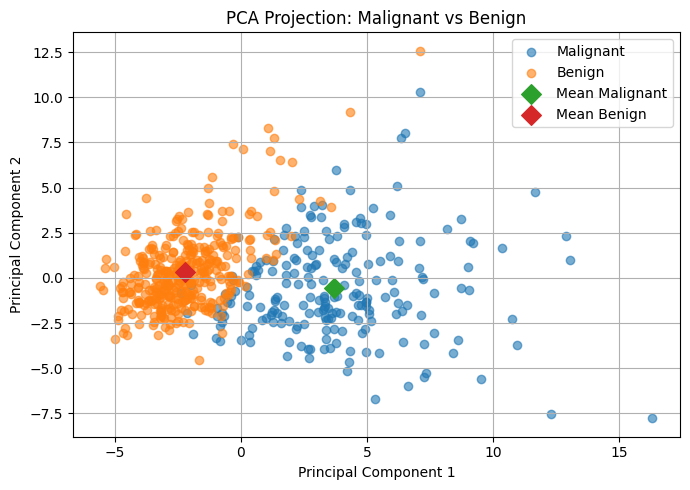

In [ ]:
# (c)
# 2D projection and class means
X2 = pca2.transform(X_std)
mean_malignant = X2[Y==0].mean(axis=0)
mean_benign = X2[Y==1].mean(axis=0)
print("Mean malignant (PC1,PC2):", mean_malignant)
print("Mean benign    (PC1,PC2):", mean_benign)

# Plot labeled 2D Scatter
plt.figure(figsize=(7,5))
plt.scatter(X2[Y==0,0], X2[Y==0,1], alpha=0.6, label='Malignant')
plt.scatter(X2[Y==1,0], X2[Y==1,1], alpha=0.6, label='Benign')
plt.scatter(mean_malignant[0], mean_malignant[1], marker='D', s=100, label='Mean Malignant')
plt.scatter(mean_benign[0], mean_benign[1], marker='D', s=100, label='Mean Benign')
plt.xlabel('Principal Component 1'); plt.ylabel('Principal Component 2'); plt.legend(); plt.title('PCA Projection: Malignant vs Benign')
plt.grid(True); plt.tight_layout()
plt.savefig('q1_pca_scatter.png')

In [ ]:
# (d)
# Reconstruction MSE from both Principal Components
X_reconstruct = pca2.inverse_transform(X2)
mse_per_sample = np.mean((X_std - X_reconstruct)**2, axis=1)
avg_mse = mse_per_sample.mean()
print("Average reconstruction MSE (per sample):", avg_mse)

Average reconstruction MSE (per sample): 0.36756792348440565


In [ ]:
# Q2_pca_Synthetic_Spectroscopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
import os

excel_path = '/content/synthetic_pca_dataset.xlsx'
sheet_name = 0
x_new = np.array([0.5, -1.0, 0.3, 0.0, 0.2])
df = pd.read_excel(excel_path, sheet_name=sheet_name)
print("Loaded dataframe shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())

Loaded dataframe shape: (400, 5)

First 5 rows:
           X1         X2          X3         X4        X5
0  13.636652  12.278138  -57.711538  17.678951  0.152177
1   2.836132   1.513431 -112.339157  -9.065892 -0.374126
2   7.695132   8.292800   71.636134  -0.127567 -0.013451
3  16.789237  16.937066   31.521533  35.440993  0.815472
4  13.592875  12.449632 -184.595117  22.514090  0.410602


In [ ]:
# (a)
# Imputation- Fill missing values in X5 using column mean imputation

expected_cols = ['X1','X2','X3','X4','X5']
if set(expected_cols).issubset(df.columns):
    data = df[expected_cols].to_numpy()
else:
    data = df.iloc[:, :5].to_numpy()
    print("Warning: expected column names X1..X5 not found; using first 5 columns.")

data_df = pd.DataFrame(data, columns=expected_cols)

# Count NaN values before imputation
nan_before = data_df.isna().sum()
total_nan_before = data_df.isna().sum().sum()
print("\nNaN count per column before imputation:\n", nan_before)
print("Number of NaN values before imputation:", total_nan_before)

# Impute missing values with column mean
imp = SimpleImputer(strategy='mean')
X_imp = imp.fit_transform(data)
print("Mean used for X5 imputation:", imp.statistics_[4])

# Convert back to DataFrame
X_imp_df = pd.DataFrame(X_imp, columns=expected_cols)

# Count NaN values after imputation
nan_after = X_imp_df.isna().sum()
total_nan_after = X_imp_df.isna().sum().sum()

print("\nNaN count per column after imputation:\n", nan_after)
print("Number of NaN values after imputation:", total_nan_after)



NaN count per column before imputation:
 X1     0
X2     0
X3     0
X4     0
X5    34
dtype: int64
Number of NaN values before imputation: 34
Mean used for X5 imputation: -0.05925270490469588

NaN count per column after imputation:
 X1    0
X2    0
X3    0
X4    0
X5    0
dtype: int64
Number of NaN values after imputation: 0


In [ ]:
# (b)
# Two PCA's

# (i) Covariance PCA on raw (unstandardized) data
print("(i) Run Covariance PCA on raw (unstandardized) data")
pca_cov = PCA(n_components=5)
pca_cov.fit(X_imp)
eig_cov = pca_cov.explained_variance_
exp_cov_pct = pca_cov.explained_variance_ratio_ * 100

# (ii) Correlation PCA on standardized data
print("(ii) Run Correlation PCA on standardized data")
scaler = StandardScaler()
X_std = scaler.fit_transform(X_imp)
pca_corr = PCA(n_components=5)
pca_corr.fit(X_std)
eig_corr = pca_corr.explained_variance_
exp_corr_pct = pca_corr.explained_variance_ratio_ * 100

(i) Run Covariance PCA on raw (unstandardized) data
(ii) Run Correlation PCA on standardized data


In [ ]:
# (c)
# Spectrum

# (i) Print eigenvalues & explained % for Covariance PCA
print("(i)")
print("Covariance PCA eigenvalues:", eig_cov)
print("Covariance PCA explained variance (%):", np.round(exp_cov_pct, 6))

# (ii) Print eigenvalues & explained % for Correlation PCA
print("\n(ii)")
print("Correlation PCA eigenvalues:", eig_corr)
print("Correlation PCA explained variance (%):", np.round(exp_corr_pct, 6))

(i)
Covariance PCA eigenvalues: [1.02220768e+04 1.30401106e+02 1.06931128e+02 8.32943018e-01
 2.16020333e-01]
Covariance PCA explained variance (%): [9.7721121e+01 1.2466100e+00 1.0222410e+00 7.9630000e-03 2.0650000e-03]

(ii)
Correlation PCA eigenvalues: [2.00711927 1.07544716 0.98824634 0.93768361 0.00403496]
Correlation PCA explained variance (%): [40.04203  21.455171 19.715514 18.706788  0.080497]


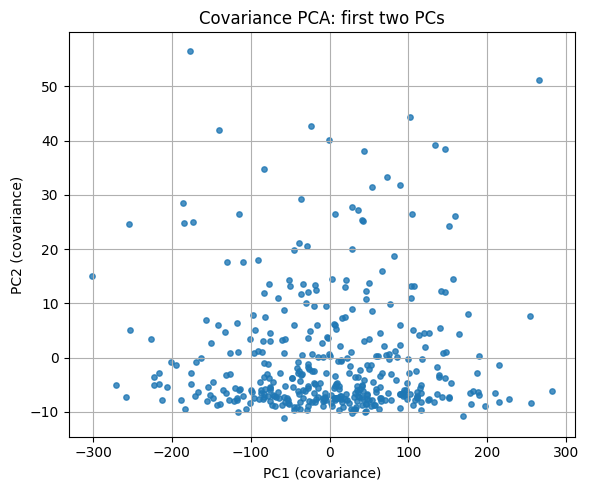

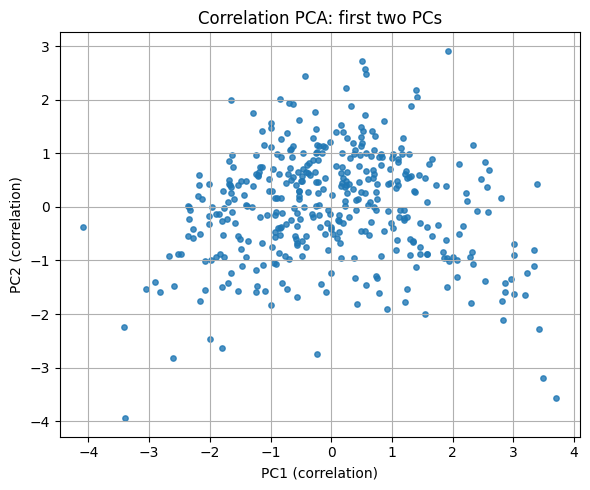

In [ ]:
# d
# PC Scatter

# Transform data to the first two PC's and plot the 2D projection and Comment on the cluster patterns
pc_cov_2 = pca_cov.transform(X_imp)[:,:2]
pc_corr_2 = pca_corr.transform(X_std)[:,:2]

plt.figure(figsize=(6,5))
plt.scatter(pc_cov_2[:,0], pc_cov_2[:,1], s=15, alpha=0.8)
plt.xlabel('PC1 (covariance)'); plt.ylabel('PC2 (covariance)')
plt.title('Covariance PCA: first two PCs')
plt.grid(True); plt.tight_layout()

plt.figure(figsize=(6,5))
plt.scatter(pc_corr_2[:,0], pc_corr_2[:,1], s=15, alpha=0.8)
plt.xlabel('PC1 (correlation)'); plt.ylabel('PC2 (correlation)')
plt.title('Correlation PCA: first two PCs')
plt.grid(True); plt.tight_layout()


The 2D scatter plots above show the data projected onto the first two principal components.
- In the covariance-based PCA plot, variables with larger variances dominate the projection,
  so the structure may be stretched along features with higher magnitude.
- In the correlation-based PCA plot, since features are standardized,
  the projection often shows clearer groupings or patterns if the dataset has correlated features.
- Typically, if the data has different scales, correlation-based PCA gives a more balanced
  representation of underlying structure or clusters.

In [ ]:
# e
# Reconstruction using first 2 PCs and compute MSE

# (i) Covariance PCA reconstruction
scores_cov = pca_cov.transform(X_imp)
scores_cov_trunc = np.zeros_like(scores_cov)
scores_cov_trunc[:, :2] = scores_cov[:, :2]
X_cov_recon = pca_cov.inverse_transform(scores_cov_trunc)
mse_cov = mean_squared_error(X_imp, X_cov_recon)

# (ii) Correlation PCA reconstruction
scores_corr = pca_corr.transform(X_std)
scores_corr_trunc = np.zeros_like(scores_corr)
scores_corr_trunc[:, :2] = scores_corr[:, :2]
X_corr_recon_std = pca_corr.inverse_transform(scores_corr_trunc)
X_corr_recon = scaler.inverse_transform(X_corr_recon_std)
mse_corr_std = mean_squared_error(X_std, X_corr_recon_std)
mse_corr_orig = mean_squared_error(X_imp, X_corr_recon)

print("\nReconstruction MSE (first 2 PCs):")
print(" (i) Covariance PCA MSE:           ", mse_cov)
print(" (ii) Correlation PCA MSE (std): ", mse_corr_std)
print("      Correlation PCA MSE (orig):", mse_corr_orig)


Reconstruction MSE (first 2 PCs):
 (i) Covariance PCA MSE:            21.54202820158463
 (ii) Correlation PCA MSE (std):  0.38502799710171165
      Correlation PCA MSE (orig): 1227.9642921162654


In [ ]:
# f
# Project a new sample x_new (raw) into both PC spaces

# For covariance PCA:
x_new = np.asarray(x_new).reshape(-1)
if x_new.shape[0] != X_imp.shape[1]:
    raise ValueError(f"x_new length {x_new.shape[0]} doesn't match data features {X_imp.shape[1]}")
x_center = x_new - X_imp.mean(axis=0)
proj_covariance = x_center.dot(pca_cov.components_[:2].T)

# For correlation PCA:
x_std_new = (x_new - scaler.mean_) / np.sqrt(scaler.var_)
proj_correlation = x_std_new.dot(pca_corr.components_[:2].T)

print("\nExample x_new (raw):", x_new)
print("Projected coords (Covariance PCA, PC1-PC2):", proj_covariance)
print("Projected coords (Correlation PCA, PC1-PC2):", proj_correlation)



Example x_new (raw): [ 0.5 -1.   0.3  0.   0.2]
Projected coords (Covariance PCA, PC1-PC2): [12.23635283  0.02343744]
Projected coords (Correlation PCA, PC1-PC2): [-0.02301655  0.10867763]


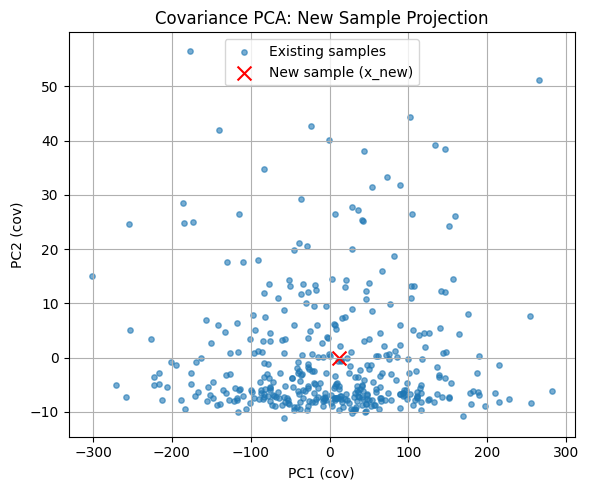

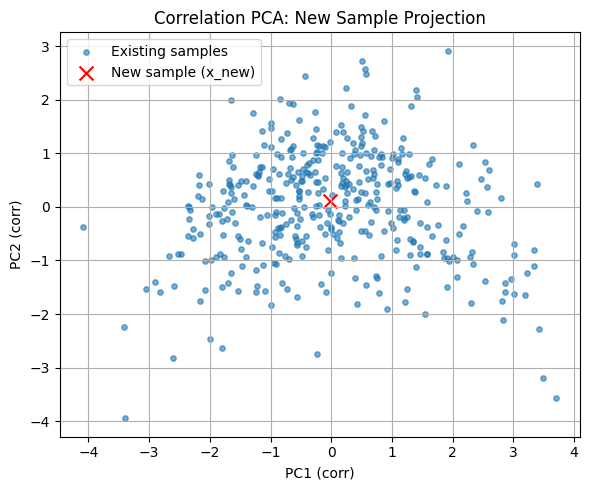

In [ ]:
pc_cov_2 = pca_cov.transform(X_imp)[:, :2]
pc_corr_2 = pca_corr.transform(X_std)[:, :2]

# Covariance PCA plot
plt.figure(figsize=(6,5))
plt.scatter(pc_cov_2[:,0], pc_cov_2[:,1], s=15, alpha=0.6, label='Existing samples')
plt.scatter(proj_covariance[0], proj_covariance[1], color='red', s=100, marker='x', label='New sample (x_new)')
plt.xlabel('PC1 (cov)')
plt.ylabel('PC2 (cov)')
plt.title('Covariance PCA: New Sample Projection')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Correlation PCA plot
plt.figure(figsize=(6,5))
plt.scatter(pc_corr_2[:,0], pc_corr_2[:,1], s=15, alpha=0.6,label='Existing samples')
plt.scatter(proj_correlation[0], proj_correlation[1], color='red', s=100, marker='x', label='New sample (x_new)')
plt.xlabel('PC1 (corr)')
plt.ylabel('PC2 (corr)')
plt.title('Correlation PCA: New Sample Projection')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [ ]:
# Q3_qp_gd_and_dual.py
import numpy as np
import matplotlib.pyplot as plt

# Given problem data
Q = np.array([[2., 1.],
              [1., 4.]])
c = np.array([5., 3.])
A = np.array([[1., 0.],
              [-1., 0.],
              [0., 1.],
              [0., -1.]])
b = np.array([1., 1., 1., 1.])


In [ ]:
# Objective and gradient
def objective(x):
    return x.T @ Q @ x + c.T @ x

def grad(x):
    return 2 * Q @ x + c

# Projection to box constraints [-1,1]^2
def proj_box(x):
    return np.clip(x, -1.0, 1.0)

Gradient Descent solution x* = [-1.    -0.125]
Objective at x* = -3.0625000000000004


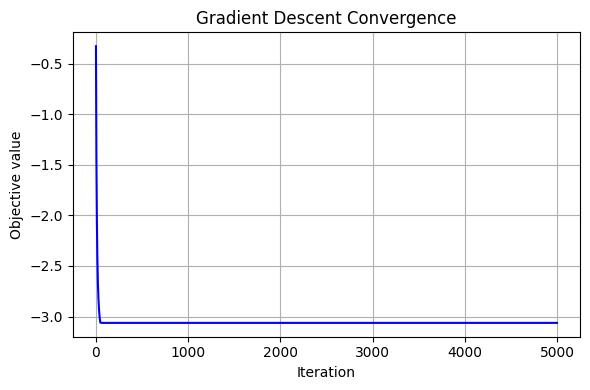

In [ ]:
# (a)
# Solve using Gradient Descent
x = np.zeros(2)
lr = 0.01
objs = []
for i in range(5000):
    x = proj_box(x - lr * grad(x))
    objs.append(objective(x))

x_opt = x
print("Gradient Descent solution x* =", x_opt)
print("Objective at x* =", objective(x_opt))

# Plot convergence of objective function
plt.figure(figsize=(6,4))
plt.plot(objs, color='blue')
plt.xlabel('Iteration')
plt.ylabel('Objective value')
plt.title('Gradient Descent Convergence')
plt.grid(True)
plt.tight_layout()
plt.show()

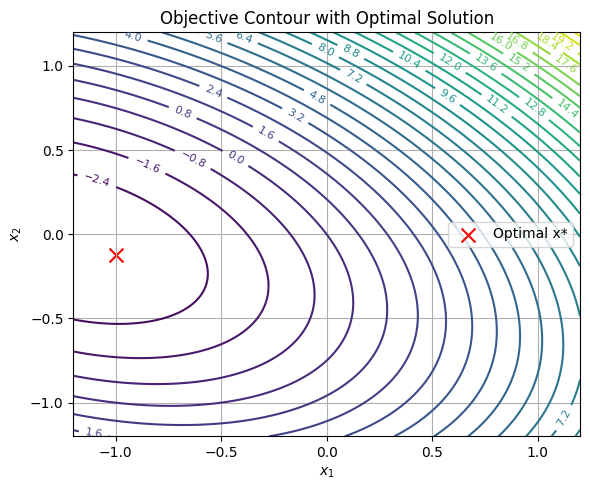

In [ ]:
# Plot the objective surface + optimal point
x1 = np.linspace(-1.2, 1.2, 200)
x2 = np.linspace(-1.2, 1.2, 200)
X1, X2 = np.meshgrid(x1, x2)
Z = 2*X1**2 + 2*X1*X2 + 4*X2**2 + 5*X1 + 3*X2

plt.figure(figsize=(6,5))
contours = plt.contour(X1, X2, Z, levels=30, cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8)
plt.scatter(x_opt[0], x_opt[1], color='red', marker='x', s=100, label='Optimal x*')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Objective Contour with Optimal Solution')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

=== Dual problem results ===
lambda* (dual variables): [0.   0.75 0.   0.  ]
Dual objective g(lambda*): -3.0625

x recovered from dual (minimizer of L wrt x at lambda*): [-1.    -0.125]
Primal objective at x_from_dual: -3.062500000000001

Primal solution (PGD) x_primal (for comparison): [-1.    -0.125]
Primal objective at x_primal: -3.0625000000000004

Duality gap (primal - dual): -4.440892098500626e-16

Feasibility check A x_from_dual - b (should be <= 0): [-2.     0.    -1.125 -0.875]
Any positive (violations)? False

Complementary slackness terms (lambda * (Ax - b)): [-0.  0. -0. -0.]

Stationarity residual (2Qx + c + A^T lambda): [0. 0.]
Stationarity norm: 1.1957467920563633e-15



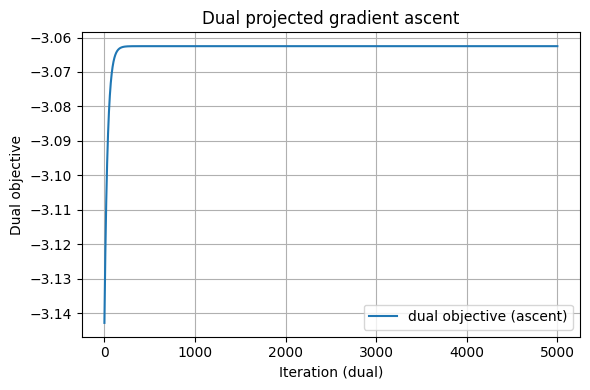

In [ ]:
# (c)
# Solve the Dual Problem and report the results

# Using gradient ascent
from numpy.linalg import inv, norm

Q = np.array([[2., 1.],
              [1., 4.]])
c = np.array([5., 3.])
A = np.array([[1., 0.],
              [-1., 0.],
              [0., 1.],
              [0., -1.]])
b = np.array([1., 1., 1., 1.])

def objective(x):
    return float(x.T @ Q @ x + c.T @ x)

# Closed-form inner minimizer for L(x, lambda): x*(lambda) = -1/2 Q^{-1} (c + A^T lambda)
Qinv = inv(Q)
def dual_val_and_x(lambda_vec):
    At_lambda = A.T @ lambda_vec
    x_star = -0.5 * Qinv @ (c + At_lambda)
    # dual value: L(x_star, lambda) = x_star^T Q x_star + c^T x_star + lambda^T (A x_star - b)
    val = float(x_star.T @ Q @ x_star + c.T @ x_star + lambda_vec.T @ (A @ x_star - b))
    return val, x_star

# Projected gradient ascent on lambda >= 0
lambda_vec = np.zeros(A.shape[0])
lr_dual = 0.05
dual_vals = []
n_iter_dual = 5000

for i in range(n_iter_dual):
    val, x_candidate = dual_val_and_x(lambda_vec)
    grad_lambda = A @ x_candidate - b               # gradient of dual wrt lambda
    lambda_vec = np.maximum(0.0, lambda_vec + lr_dual * grad_lambda)  # projection to lambda >= 0
    dual_vals.append(val)

# Final dual evaluation
dual_val, x_from_dual = dual_val_and_x(lambda_vec)
lambda_star = lambda_vec.copy()

def proj_box(x):
    return np.clip(x, -1.0, 1.0)
x = np.zeros(2)
lr_primal = 0.01
for i in range(5000):
    x = proj_box(x - lr_primal * (2 * Q @ x + c))
x_primal = x.copy()
primal_obj = objective(x_primal)

print("=== Dual problem results ===")
print("lambda* (dual variables):", np.round(lambda_star, 6))
print("Dual objective g(lambda*):", dual_val)
print()
print("x recovered from dual (minimizer of L wrt x at lambda*):", np.round(x_from_dual, 6))
print("Primal objective at x_from_dual:", objective(x_from_dual))
print()
print("Primal solution (PGD) x_primal (for comparison):", np.round(x_primal, 6))
print("Primal objective at x_primal:", primal_obj)
print()

# Duality gap
duality_gap = primal_obj - dual_val
print("Duality gap (primal - dual):", duality_gap)

# Feasibility (should be <= 0 for A x - b)
Ax_minus_b = A @ x_from_dual - b
print("\nFeasibility check A x_from_dual - b (should be <= 0):", np.round(Ax_minus_b, 8))
print("Any positive (violations)?", np.any(Ax_minus_b > 1e-8))

# Complementary slackness: lambda_i * (A x - b)_i ≈ 0
comp_slack = lambda_star * (A @ x_from_dual - b)
print("\nComplementary slackness terms (lambda * (Ax - b)):", np.round(comp_slack, 8))

# Stationarity: 2Qx + c + A^T lambda ≈ 0
stationarity = 2 * Q @ x_from_dual + c + A.T @ lambda_star
print("\nStationarity residual (2Qx + c + A^T lambda):", np.round(stationarity, 8))
print("Stationarity norm:", norm(stationarity))
print()

# Plot dual objective convergence
plt.figure(figsize=(6,4))
plt.plot(dual_vals, label='dual objective (ascent)')
plt.xlabel('Iteration (dual)')
plt.ylabel('Dual objective')
plt.title('Dual projected gradient ascent')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Strong duality is observed (primal optimum equals dual optimum).

Linear inequality constraints and existence of a strictly feasible point like x=0 satisfy Slater’s condition. For convex problems, Slater’s condition guarantees zero duality gap → strong duality holds.

In conclusion, strong duality holds here (dual optimum equals primal optimum and KKT conditions are satisfied).

In [ ]:
# Using Lagrangian

import numpy as np
from numpy.linalg import inv, norm

Q = np.array([[2., 1.],
              [1., 4.]])
c = np.array([5., 3.])
A = np.array([[1., 0.],
              [-1., 0.],
              [0., 1.],
              [0., -1.]])
b = np.array([1., 1., 1., 1.])

Qinv = inv(Q)

# Dual (minimization form) derived from Lagrangian elimination:
# g(lambda) = -1/4 (c + A^T lambda)^T Q^{-1} (c + A^T lambda) - lambda^T b  (concave)
# minimize f(lambda) = - g(lambda) = 1/4 (c + A^T lambda)^T Q^{-1} (c + A^T lambda) + lambda^T b

def dual_primal_from_lambda(lam):
    lam = np.asarray(lam).reshape(-1)
    y = c + A.T @ lam
    f = 0.25 * float(y.T @ Qinv @ y) + float(lam @ b)   # scalar
    return f

def dual_grad(lam):
    lam = np.asarray(lam).reshape(-1)
    y = c + A.T @ lam
    # gradient of f: 0.5 * A @ (Qinv @ y) + b
    grad = 0.5 * (A @ (Qinv @ y)) + b
    return grad

def primal_from_lambda(lam):
    lam = np.asarray(lam).reshape(-1)
    y = c + A.T @ lam
    x_star = -0.5 * (Qinv @ y)
    return x_star

use_scipy = True
try:
    from scipy.optimize import minimize
except Exception:
    use_scipy = False

if use_scipy:
    bounds = [(0, None)] * A.shape[0]
    lam0 = np.zeros(A.shape[0])
    res = minimize(fun=dual_primal_from_lambda, x0=lam0, jac=dual_grad, bounds=bounds,
                   method='L-BFGS-B', options={'ftol':1e-12, 'maxiter':10000})
    lambda_star = np.clip(res.x, 0, None)
    method_used = "scipy L-BFGS-B"
else:
    lam = np.zeros(A.shape[0])
    lr = 0.05
    for it in range(20000):
        g = dual_grad(lam)
        lam = lam - lr * g
        # projection
        lam = np.maximum(0.0, lam)
        if it % 1000 == 0 and it > 0:
            pass
    lambda_star = lam
    method_used = "projected gradient (numpy fallback)"

# Recover primal x from lambda*
x_from_dual = primal_from_lambda(lambda_star)
primal_obj = float(x_from_dual.T @ Q @ x_from_dual + c.T @ x_from_dual)
dual_val = -dual_primal_from_lambda(lambda_star)   # g(lambda*) = -f(lambda*)

print("Method used:", method_used)
print("lambda*:", np.round(lambda_star, 6))
print("Dual objective g(lambda*):", np.round(dual_val, 12))
print("x recovered from dual (minimizer of L wrt x at lambda*):", np.round(x_from_dual, 6))
print("Primal objective at x_from_dual:", np.round(primal_obj, 12))

Ax_minus_b = A @ x_from_dual - b
stationarity = 2 * Q @ x_from_dual + c + A.T @ lambda_star
comp_slack = lambda_star * (Ax_minus_b)

print("\nFeasibility check A x_from_dual - b (should be <= 0):", np.round(Ax_minus_b, 12))
print("Any positive (violations)?", np.any(Ax_minus_b > 1e-8))
print("\nComplementary slackness (lambda * (Ax - b)):", np.round(comp_slack, 12))
print("\nStationarity residual (2Qx + c + A^T lambda):", np.round(stationarity, 12))
print("Stationarity norm:", norm(stationarity))
print("\nDuality gap (primal - dual):", np.round(primal_obj - dual_val, 12))


Method used: scipy L-BFGS-B
lambda*: [0.   0.75 0.   0.  ]
Dual objective g(lambda*): -3.0625
x recovered from dual (minimizer of L wrt x at lambda*): [-1.    -0.125]
Primal objective at x_from_dual: -3.0625

Feasibility check A x_from_dual - b (should be <= 0): [-2.     0.    -1.125 -0.875]
Any positive (violations)? False

Complementary slackness (lambda * (Ax - b)): [-0.  0. -0. -0.]

Stationarity residual (2Qx + c + A^T lambda): [-0.  0.]
Stationarity norm: 3.3306690738754696e-16

Duality gap (primal - dual): 0.0
